# Forest Carbon Stock Change Estimation
## Little Andaman Island, India | 2020–2022

This notebook estimates above-ground biomass density (AGBD) change on Little Andaman Island using NASA GEDI LiDAR and ESA Sentinel-2 satellite imagery. A Gradient Boosting model trained on GEDI footprint-level biomass measurements is applied wall-to-wall across the island using Sentinel-2 spectral data as a spatial scaffold, producing carbon stock estimates for 2020 and 2022 and quantifying net change over the period.

**Primary purpose:** Demonstrate a reproducible geospatial data pipeline for environmental consulting applications - specifically the acquisition, preprocessing, fusion, and modelling of large-scale heterogeneous satellite datasets.

**Study area:** Little Andaman Island, Andaman Islands, India (~734 km², >93% intact tropical forest)  
**Data sources:** NASA GEDI L4A v2.1 + L2A v2 | ESA Sentinel-2 L2A  
**Pipeline:** GEDI Harmony API -> OpenEO -> HDF5 extraction -> raster fusion -> GBR model -> carbon accounting  
**Methodology reference:** IPCC 2006 Guidelines | Verra VM0048 (REDD+) | VT0005 (remote sensing biomass)

## 00 - Configuration & Imports

In [1]:
import os
import json
import h5py
import joblib
import requests as re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import openeo
import contextily as ctx
from shapely.geometry import box
from pathlib import Path
from datetime import datetime, date
from dateutil.relativedelta import relativedelta
from concurrent.futures import TimeoutError
from scipy.spatial import cKDTree
from harmony import Client, Collection, Request, BBox
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

In [2]:
# Creating project root and subdirectories:
PROJECT_ROOT = Path(__file__).resolve().parent if '__file__' in dir() else Path.cwd()

DATA_DIR   = PROJECT_ROOT / 'data'
GEDI_DIR   = DATA_DIR    / 'gedi'
S2_DIR     = DATA_DIR    / 'sentinel_2'
OUTPUT_DIR = PROJECT_ROOT / 'output'
MODEL_DIR  = PROJECT_ROOT / 'model'
FIGURES_DIR = PROJECT_ROOT / 'figures'

for d in [DATA_DIR, GEDI_DIR, S2_DIR, OUTPUT_DIR, MODEL_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Study area: Little Andaman Island (lon_min, lat_min, lon_max, lat_max)
BBOX = (92.303245, 10.504269, 92.665951, 10.937400)

# Acquisition windows - Jan–Apr dry season minimises cloud cover
PERIOD_1 = ('2020-01-01', '2020-04-30')
PERIOD_2 = ('2022-01-01', '2022-04-30')

BEAMS = [
    'BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011',
    'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011',
]

# Feature order must be preserved consistently across training and prediction
FEATURES = [
    'rh98',
    'NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI',
    'B02_Blue', 'B04_Red', 'B08_NIR', 'B11_SWIR1', 'B12_SWIR2',
]
TARGET       = 'agbd'
RANDOM_STATE = 42

# Carbon conversion constants (IPCC 2006 defaults for tropical forest)
CARBON_FRACTION = 0.47   # fraction of dry biomass that is carbon
C_TO_CO2        = 44/12  # molecular weight ratio C -> CO2
PIXEL_AREA_HA   = 0.01   # 10m x 10m = 0.01 ha

print(f'Project root:    {PROJECT_ROOT}')
print(f'Study area bbox: {BBOX}')
print(f'Period 1:        {PERIOD_1[0]} - {PERIOD_1[1]}')
print(f'Period 2:        {PERIOD_2[0]} - {PERIOD_2[1]}')
print(f'Directories OK:  {[d.name for d in [DATA_DIR, GEDI_DIR, S2_DIR, OUTPUT_DIR, MODEL_DIR, FIGURES_DIR]]}')

Project root:    c:\Users\simra\Documents\Carbon credit estimation project
Study area bbox: (92.303245, 10.504269, 92.665951, 10.9374)
Period 1:        2020-01-01 - 2020-04-30
Period 2:        2022-01-01 - 2022-04-30
Directories OK:  ['data', 'gedi', 'sentinel_2', 'output', 'model', 'figures']


## 01 - GEDI Data Acquisition

GEDI (Global Ecosystem Dynamics Investigation) is a LiDAR instrument aboard the ISS that measures forest canopy structure along orbital tracks. Two data products are used:

- **L4A**: footprint-level above-ground biomass density (AGBD, Mg/ha) - the prediction target
- **L2A**: relative height metrics including rh98 (98th percentile canopy height) - the primary predictor

Data is accessed via NASA's Harmony API, which subsets HDF5 granules to the study area bounding box before download, keeping file sizes manageable (~5–20 MB vs ~1 GB for full granules).

**L4A** is downloaded as a single annual request - the subsetter handles this reliably.  
**L2A** is downloaded in monthly batches - Harmony's L2A subsetter hangs on large temporal requests, so batching by month keeps each job small enough to complete within the timeout window.

Acquisition window: January–April for both years. This dry-season window minimises cloud interference in the co-registered Sentinel-2 imagery and ensures temporal consistency between the two years.

In [3]:
# Connecting with Harmony and getting Concept ID for L2A and L4A
harmony_client = Client()

def get_concept_id(doi):
    url = f'https://cmr.earthdata.nasa.gov/search/collections.json?doi={doi}'
    return re.get(url).json()['feed']['entry'][0]['id']

CONCEPT_L4A = get_concept_id('10.3334/ORNLDAAC/2056')
CONCEPT_L2A = get_concept_id('10.5067/GEDI/GEDI02_A.002')

print(f'L2A Concept ID: {CONCEPT_L2A}')
print(f'L4A Concept ID: {CONCEPT_L4A}')

def beam_vars(variables):
    """Build per-beam variable paths for Harmony subsetting."""
    return [f'/{b}/{v}' for b in BEAMS for v in variables]

VARS_L4A = beam_vars([
    'agbd', 'l4_quality_flag', 'lat_lowestmode', 'lon_lowestmode',
    'land_cover_data/pft_class'
])
VARS_L2A = beam_vars(['rh', 'lat_lowestmode', 'lon_lowestmode'])

HARMONY_BBOX = BBox(w=BBOX[0], s=BBOX[1], e=BBOX[2], n=BBOX[3])

L2A Concept ID: C2142771958-LPCLOUD
L4A Concept ID: C2237824918-ORNL_CLOUD


In [4]:
def download_l4a(period, out_dir, label):
    """Download GEDI L4A for a given period via Harmony as a single request."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    start = datetime.strptime(period[0], '%Y-%m-%d')
    stop  = datetime.strptime(period[1], '%Y-%m-%d')
    request = Request(
        collection=Collection(id=CONCEPT_L4A),
        variables=VARS_L4A,
        temporal={'start': start, 'stop': stop},
        spatial=HARMONY_BBOX,
        ignore_errors=True,
    )
    job_id = harmony_client.submit(request)
    print(f'[{label} L4A] Job: {job_id}')
    harmony_client.result_json(job_id, show_progress=True)
    files = []
    futures = harmony_client.download_all(job_id, directory=str(out_dir), overwrite=False)
    for f in futures:
        try:
            result = f.result(timeout=120)
            if result and result.endswith('subsetted.h5'):
                print(f'  OK: {Path(result).name}')
                files.append(result)
        except TimeoutError:
            print('  TIMEOUT - skipping')
        except Exception as e:
            print(f'  ERROR: {e}')
    print(f'[{label} L4A] {len(files)} files downloaded.')
    return files


def download_l2a(period, out_dir, label):
    """
    Download GEDI L2A in monthly batches.

    The Harmony L2A subsetter hangs on multi-month requests - monthly batching
    keeps each job small enough to complete within the timeout window.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    start   = datetime.strptime(period[0], '%Y-%m-%d')
    stop    = datetime.strptime(period[1], '%Y-%m-%d')
    windows = []
    current = start
    while current <= stop:
        month_end = min(current + relativedelta(months=1) - relativedelta(days=1), stop)
        windows.append((current, month_end))
        current += relativedelta(months=1)
    files = []
    for w_start, w_stop in windows:
        month_label = w_start.strftime('%b %Y')
        print(f'  [{label} L2A] {month_label}')
        try:
            request = Request(
                collection=Collection(id=CONCEPT_L2A),
                variables=VARS_L2A,
                temporal={'start': w_start, 'stop': w_stop},
                spatial=HARMONY_BBOX,
                ignore_errors=True,
            )
            job_id  = harmony_client.submit(request)
            harmony_client.result_json(job_id, show_progress=False)
            futures = harmony_client.download_all(job_id, directory=str(out_dir), overwrite=False)
            for f in futures:
                try:
                    result = f.result(timeout=180)
                    if result and result.endswith('subsetted.h5'):
                        print(f'    OK: {Path(result).name}')
                        files.append(result)
                except TimeoutError:
                    print('    TIMEOUT - skipping')
                except Exception as e:
                    print(f'    ERROR: {e}')
        except Exception as e:
            print(f'    Job failed: {e} - skipping {month_label}')
    print(f'[{label} L2A] {len(files)} files downloaded.')
    return files

## 02 - GEDI Preprocessing & Quality Filtering

Raw GEDI HDF5 files contain all orbital shots globally - we extract only the variables needed and apply quality filters to retain scientifically valid observations.

**Extraction:**
- L4A: AGBD, quality flag, coordinates, plant functional type (PFT) class
- L2A: rh98 (index 98 of the relative height array), coordinates

**Join:** L4A and L2A are joined on lat/lon rounded to 6 decimal places (~0.1m precision). This matches footprints from the two products without requiring a spatial join.

**Quality filters applied:**
- `l4_quality_flag == 1`: retains only high-quality AGBD retrievals
- `pft_class 1–5`: trees and shrubs only - excludes water, urban, bare ground
- `0 < agbd < 600 Mg/ha`: physical plausibility range for tropical forest

Corrupt HDF5 files (incomplete downloads) are caught and skipped automatically.

In [5]:
def read_l2a(files):
    """Extract rh98 and coordinates from L2A subsetted HDF5 files."""
    records = []
    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as hf:
                for beam in BEAMS:
                    if beam not in hf:
                        continue
                    b = hf[beam]
                    if 'rh' not in b or 'lat_lowestmode' not in b:
                        continue
                    if b['lat_lowestmode'].shape[0] == 0:
                        continue
                    lat = b['lat_lowestmode'][:]
                    lon = b['lon_lowestmode'][:]
                    rh  = b['rh'][:]
                    records.append(pd.DataFrame({
                        'lat_key': np.round(lat, 6),
                        'lon_key': np.round(lon, 6),
                        'rh98':    rh[:, 98],
                        'rh100':   rh[:, 100],
                    }))
        except OSError:
            print(f'  CORRUPT: {Path(fpath).name} - skipping')
    df = pd.concat(records, ignore_index=True)
    return df.drop_duplicates(subset=['lat_key', 'lon_key'])


def read_l4a(files):
    """Extract AGBD and coordinates from L4A subsetted HDF5 files."""
    records = []
    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as hf:
                for beam in BEAMS:
                    if beam not in hf:
                        continue
                    b = hf[beam]
                    if 'agbd' not in b or 'lat_lowestmode' not in b:
                        continue
                    if b['lat_lowestmode'].shape[0] == 0:
                        continue
                    lat = b['lat_lowestmode'][:]
                    lon = b['lon_lowestmode'][:]
                    records.append(pd.DataFrame({
                        'lat_key':         np.round(lat, 6),
                        'lon_key':         np.round(lon, 6),
                        'lat':             lat,
                        'lon':             lon,
                        'agbd':            b['agbd'][:],
                        'l4_quality_flag': b['l4_quality_flag'][:],
                        'pft_class':       b['land_cover_data/pft_class'][:],
                    }))
        except OSError:
            print(f'  CORRUPT: {Path(fpath).name} - skipping')
    return pd.concat(records, ignore_index=True)


def build_gedi_gdf(l4a_files, l2a_files, label):
    """
    Join L4A and L2A on footprint coordinates, apply quality filters,
    and return a clean GeoDataFrame.

    Join key: lat/lon rounded to 6 decimal places (~0.1m precision).
    Quality filters: l4_quality_flag == 1, pft_class 1-5, 0 < agbd < 600.
    """
    print(f'[{label}] Reading L4A...')
    l4a = read_l4a(l4a_files)
    print(f'  L4A shots loaded: {len(l4a):,}')

    print(f'[{label}] Reading L2A...')
    l2a = read_l2a_subset(l2a_files, BBOX)
    print(f'  L2A shots loaded: {len(l2a):,}')

    print(f'[{label}] Joining on lat/lon key...')
    merged = l4a.merge(
        l2a[['lat_key', 'lon_key', 'rh98', 'rh100']],
        on=['lat_key', 'lon_key'], how='inner'
    )
    print(f'  After join: {len(merged):,}')

    mask = (
        (merged['l4_quality_flag'] == 1) &
        (merged['pft_class'].between(1, 5)) &
        (merged['agbd'] > 0) &
        (merged['agbd'] < 600)
    )
    clean = merged[mask].drop_duplicates(subset=['lat_key', 'lon_key']).copy()
    print(f'  After QC + dedup: {len(clean):,}')
    print(f'  AGBD mean: {clean["agbd"].mean():.1f} Mg/ha')
    print(f'  rh98 mean: {clean["rh98"].mean():.1f} m')

    return gpd.GeoDataFrame(
        clean,
        geometry=gpd.points_from_xy(clean['lon'], clean['lat']),
        crs='EPSG:4326'
    )

In [6]:
# Run once — skip if data already downloaded
# l4a_files_2020 = download_l4a(PERIOD_1, GEDI_DIR / '2020', '2020')
#l4a_files_2022 = download_l4a(PERIOD_2, GEDI_DIR / '2022', '2022')

# l2a_files_2020 = download_l2a(PERIOD_1, GEDI_DIR / '2020', '2020')
#l2a_files_2022 = download_l2a(PERIOD_2, GEDI_DIR / '2022', '2022')

In [7]:
import earthaccess
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

earthaccess.login(strategy='netrc')  # or 'interactive' if netrc not set up

def download_l2a_direct(period, out_dir, label):
    """
    Download L2A granules directly via earthaccess (bypasses Harmony subsetter).
    Files are full orbit granules — we subset to bbox manually after download.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    results = earthaccess.search_data(
        concept_id = CONCEPT_L2A,
        temporal   = (period[0], period[1]),
        bounding_box = BBOX,  # (west, south, east, north)
    )
    print(f"[{label} L2A] {len(results)} granules found")

    files = earthaccess.download(results, local_path=str(out_dir))
    print(f"[{label} L2A] {len(files)} files downloaded")
    return [str(f) for f in files]


def read_l2a_subset(files, bbox):
    """
    Read L2A files and spatially subset to bbox manually.
    Replaces the Harmony-subsetted read_l2a() function.
    bbox = (west, south, east, north)
    """
    west, south, east, north = bbox
    records = []

    for fpath in files:
        try:
            with h5py.File(fpath, 'r') as hf:
                for beam in BEAMS:
                    if beam not in hf:
                        continue
                    b = hf[beam]
                    if 'rh' not in b or 'lat_lowestmode' not in b:
                        continue
                    lat = b['lat_lowestmode'][:]
                    lon = b['lon_lowestmode'][:]

                    # Spatial subset — this is what Harmony was doing server-side
                    mask = (
                        (lat >= south) & (lat <= north) &
                        (lon >= west)  & (lon <= east)
                    )
                    if mask.sum() == 0:
                        continue

                    rh = b['rh'][:]
                    records.append(pd.DataFrame({
                        'lat_key': np.round(lat[mask], 6),
                        'lon_key': np.round(lon[mask], 6),
                        'rh98':    rh[mask, 98],
                        'rh100':   rh[mask, 100],
                    }))
                    print(f"  {beam}: {mask.sum()} shots in bbox")

        except OSError:
            print(f"  CORRUPT: {Path(fpath).name} — skipping")

    if not records:
        print("  WARNING: no shots found in bbox across all files")
        return pd.DataFrame(columns=['lat_key', 'lon_key', 'rh98', 'rh100'])

    df = pd.concat(records, ignore_index=True)
    df = df.drop_duplicates(subset=['lat_key', 'lon_key'])
    print(f"  Total after dedup: {len(df):,} shots")
    return df

In [8]:
l4a_files_2020 = sorted(GEDI_DIR.glob('2020/*GEDI04_A*subsetted.h5'))
l2a_files_2020 = sorted(GEDI_DIR.glob('2020/*GEDI02_A*subsetted.h5'))
l4a_files_2022 = sorted(GEDI_DIR.glob('2022/*GEDI04_A*subsetted.h5'))
l2a_files_2022 = sorted(GEDI_DIR.glob('2022/*GEDI02_A*subsetted.h5'))

gedi_2020 = build_gedi_gdf(l4a_files_2020, l2a_files_2020, '2020')
gedi_2022 = build_gedi_gdf(l4a_files_2022, l2a_files_2022, '2022')

gedi_2020.to_file(str(OUTPUT_DIR / 'gedi_2020_clean.gpkg'), driver='GPKG')
gedi_2022.to_file(str(OUTPUT_DIR / 'gedi_2022_clean.gpkg'), driver='GPKG')
print(f'Saved: gedi_2020_clean.gpkg ({len(gedi_2020):,} shots)')
print(f'Saved: gedi_2022_clean.gpkg ({len(gedi_2022):,} shots)')

[2020] Reading L4A...
  L4A shots loaded: 30,396
[2020] Reading L2A...
  BEAM0000: 954 shots in bbox
  BEAM0001: 975 shots in bbox
  BEAM0010: 994 shots in bbox
  BEAM0011: 1017 shots in bbox
  BEAM0101: 1038 shots in bbox
  BEAM0110: 1037 shots in bbox
  BEAM1000: 1037 shots in bbox
  BEAM1011: 1031 shots in bbox
  BEAM0000: 984 shots in bbox
  BEAM0001: 1004 shots in bbox
  BEAM0010: 1019 shots in bbox
  BEAM0011: 1037 shots in bbox
  BEAM0101: 1033 shots in bbox
  BEAM0110: 1036 shots in bbox
  BEAM1000: 1028 shots in bbox
  BEAM1011: 1036 shots in bbox
  BEAM0000: 26 shots in bbox
  BEAM0001: 48 shots in bbox
  BEAM0010: 63 shots in bbox
  BEAM0011: 85 shots in bbox
  BEAM0101: 118 shots in bbox
  BEAM0110: 139 shots in bbox
  BEAM1000: 164 shots in bbox
  BEAM1011: 193 shots in bbox
  BEAM0000: 405 shots in bbox
  BEAM0001: 383 shots in bbox
  BEAM0010: 368 shots in bbox
  BEAM0011: 346 shots in bbox
  BEAM0101: 313 shots in bbox
  BEAM0110: 291 shots in bbox
  BEAM1000: 258 shots

### GEDI Track Coverage

GEDI samples the island along discrete orbital tracks rather than continuously. The plot below shows footprint locations for both years, illustrating the inter-track spacing and the coverage difference between 2020 (7,722 shots) and 2022 (4,297 shots). The sparser 2022 coverage is a consequence of one granule being unavailable via the Harmony subsetter and has implications for IDW interpolation quality in Section 05.

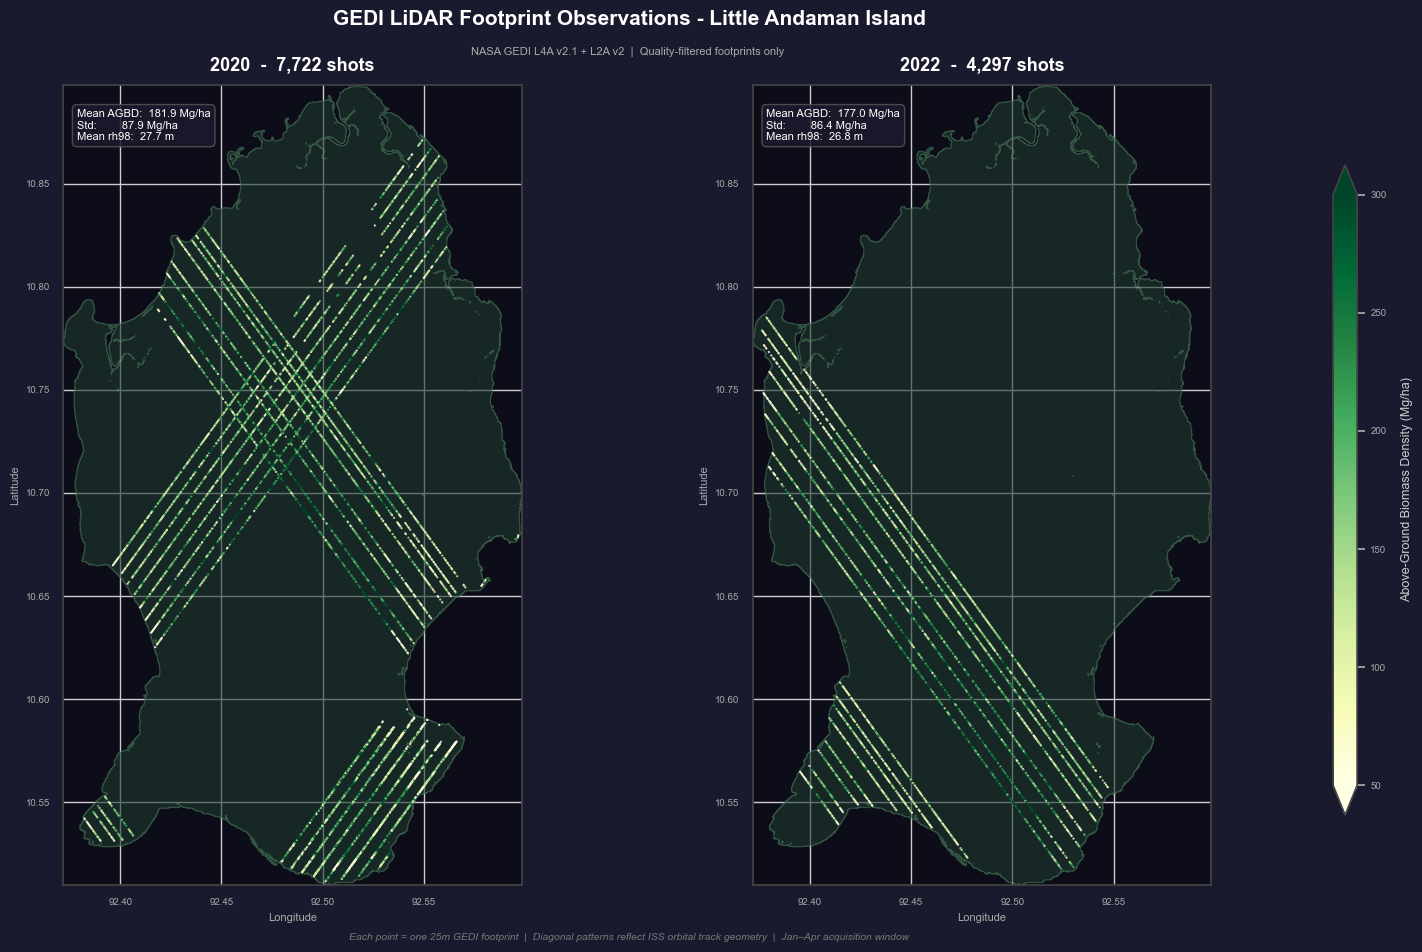

In [9]:
from rasterio.features import shapes
from shapely.geometry import shape

def extract_island_outline(s2_path):
    with rasterio.open(s2_path) as src:
        nir       = src.read(src.descriptions.index('B08_NIR') + 1)
        transform = src.transform
        crs       = src.crs
    land_mask = (nir > 0.05).astype(np.uint8)
    polys = [shape(geom) for geom, val in shapes(land_mask, transform=transform) if val == 1]
    gdf   = gpd.GeoDataFrame(geometry=polys, crs=crs)
    gdf['area'] = gdf.geometry.area
    return gdf.nlargest(1, 'area')

island = extract_island_outline(S2_DIR / 's2_features_2020.tif').to_crs('EPSG:4326')
xmin, ymin, xmax, ymax = island.total_bounds

agbd_vmin = 50
agbd_vmax = 300
cmap      = plt.cm.YlGn
norm      = mcolors.Normalize(vmin=agbd_vmin, vmax=agbd_vmax)

fig, axes = plt.subplots(1, 2, figsize=(16, 10), facecolor='#1a1a2e')
fig.subplots_adjust(wspace=0.08, left=0.05, right=0.88, top=0.88, bottom=0.08)

# Compute shared extent from the island so both panels are identical
xmin, ymin, xmax, ymax = island.total_bounds

for ax, gdf, label in zip(axes, [gedi_2020, gedi_2022], ['2020', '2022']):
    ax.set_facecolor('#0d0d1a')

    island.plot(ax=ax, facecolor='#1e3a2f', edgecolor='#4a7c59',
                linewidth=0.8, alpha=0.6)

    gdf_wgs = gdf.to_crs('EPSG:4326')
    x    = [pt.x for pt in gdf_wgs.geometry]
    y    = [pt.y for pt in gdf_wgs.geometry]
    agbd = gdf_wgs['agbd'].values

    ax.scatter(x, y, c=agbd, cmap=cmap, norm=norm,
               s=2.5, alpha=0.85, linewidths=0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f'{label}  -  {len(gdf):,} shots',
                 color='white', fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=8)
    ax.set_ylabel('Latitude', color='#aaaaaa', fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

    ax.text(
        0.03, 0.97,
        f'Mean AGBD:  {agbd.mean():.1f} Mg/ha\n'
        f'Std:        {agbd.std():.1f} Mg/ha\n'
        f'Mean rh98:  {gdf["rh98"].mean():.1f} m',
        transform=ax.transAxes, color='white', fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e',
                  edgecolor='#555555', alpha=0.85),
    )

cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.65])
sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, extend='both')
cb.set_label('Above-Ground Biomass Density (Mg/ha)',
             color='#cccccc', fontsize=9, labelpad=10)
cb.ax.tick_params(colors='#aaaaaa', labelsize=7)
cb.outline.set_edgecolor('#444444')

fig.text(0.46, 0.94, 'GEDI LiDAR Footprint Observations - Little Andaman Island',
         ha='center', color='white', fontsize=15, fontweight='bold')
fig.text(0.46, 0.91,
         'NASA GEDI L4A v2.1 + L2A v2  |  Quality-filtered footprints only ',
         ha='center', color='#aaaaaa', fontsize=8)
fig.text(0.46, 0.025,
         'Each point = one 25m GEDI footprint  |  Diagonal patterns reflect ISS orbital track geometry  |  Jan–Apr acquisition window',
         ha='center', color='#777777', fontsize=7.5, style='italic')

plt.savefig(FIGURES_DIR / 'gedi_tracks.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## 03 - Sentinel-2 Acquisition

Sentinel-2 L2A surface reflectance composites are downloaded via OpenEO on the Copernicus Data Space Ecosystem. A cloud-masked median composite collapses the full acquisition window into a single clean image per year.

**Cloud masking:** The Scene Classification Layer (SCL) is used to retain only vegetation (class 4) and bare soil (class 5) pixels. All other classes - including cloud, cloud shadow, water, and snow - are masked before compositing.

**Median composite:** Taking the pixel-wise median across all valid acquisitions in the window removes remaining cloud artefacts and reduces seasonal noise, producing one representative reflectance value per pixel.

**Output:** Two GeoTIFF files in EPSG:32646 (UTM Zone 46N), 10m resolution, covering the full study area bbox.

In [10]:
connection = openeo.connect(
    'https://openeofed.dataspace.copernicus.eu/'
).authenticate_oidc()

def download_s2(period, out_path, label):
    """
    Download a cloud-masked Sentinel-2 median composite via OpenEO.

    Cloud masking uses the Scene Classification Layer (SCL):
    only vegetation (4) and bare soil (5) pixels are retained.
    A median composite collapses the time dimension, giving one
    clean value per pixel across the acquisition window.
    """
    bbox_dict = {'west': BBOX[0], 'south': BBOX[1], 'east': BBOX[2], 'north': BBOX[3]}
    s2 = connection.load_collection(
        'SENTINEL2_L2A',
        spatial_extent=bbox_dict,
        temporal_extent=list(period),
        bands=['B02', 'B04', 'B08', 'B11', 'B12', 'SCL'],
    )
    scl          = s2.band('SCL')
    mask         = ~((scl == 4) | (scl == 5))
    s2_masked    = s2.mask(mask)
    s2_composite = s2_masked.reduce_dimension(dimension='t', reducer='median')
    job = s2_composite.execute_batch(
        title=f'S2_LittleAndaman_{label}',
        outputfile=str(out_path),
        job_options={
            'executor-memory':         '2G',
            'executor-memoryOverhead': '3G',
            'executor-cores':          '2',
        }
    )
    print(f'[S2 {label}] Job: {job.job_id} | Saved: {out_path}')
    return job.job_id

Authenticated using refresh token.


In [11]:
# job_id_2020 = download_s2(PERIOD_1, S2_DIR / 's2_raw_2020.tiff', '2020')
# job_id_2022 = download_s2(PERIOD_2, S2_DIR / 's2_raw_2022.tiff', '2022')

## 04 - Sentinel-2 Index Computation

Raw band reflectances (scaled from DN to 0–1 by dividing by 10,000) are used to compute five spectral indices alongside the five raw bands, producing a 10-band feature raster.

| Index | Formula | Sensitivity |
|-------|---------|-------------|
| NDVI  | (NIR − Red) / (NIR + Red) | Vegetation density |
| EVI   | 2.5 x (NIR − Red) / (NIR + 6xRed − 7.5xBlue + 1) | Canopy structure, reduces soil noise |
| NDMI  | (NIR − SWIR1) / (NIR + SWIR1) | Canopy moisture |
| NBR   | (NIR − SWIR2) / (NIR + SWIR2) | Burn ratio, forest disturbance |
| SAVI  | 1.5 x (NIR − Red) / (NIR + Red + 0.5) | Vegetation with soil correction |

All indices are clipped to [−1, 1]. A small epsilon (1e-10) is added to denominators to avoid division by zero in water or shadow pixels.

**Note on optical saturation:** In dense tropical forest with AGBD > ~150 Mg/ha, spectral indices plateau and lose sensitivity to biomass variation. The model evaluation in Section 06 quantifies this empirically, and the feature relationship plots in Section 05 show it directly.

In [12]:
def compute_s2_features(raw_path, out_path, label):
    """
    Read raw S2 bands, compute spectral indices, save 10-band feature raster.
    Output band order matches FEATURES (excluding rh98).
    """
    with rasterio.open(raw_path) as src:
        profile    = src.profile.copy()
        band_names = src.descriptions
        data       = src.read().astype(np.float32)

    print(f'[S2 {label}] Bands: {band_names}')
    print(f'[S2 {label}] Shape: {data.shape}, CRS: {src.crs}, Res: {src.res}')

    bn    = {name: i for i, name in enumerate(band_names)}
    eps   = 1e-10

    # Reflectance scaling: DN -> [0, 1]
    blue  = data[bn['B02']] / 10000.0
    red   = data[bn['B04']] / 10000.0
    nir   = data[bn['B08']] / 10000.0
    swir1 = data[bn['B11']] / 10000.0
    swir2 = data[bn['B12']] / 10000.0

    NDVI = (nir - red)   / (nir + red   + eps)
    EVI  = 2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + eps)
    NDMI = (nir - swir1) / (nir + swir1 + eps)
    NBR  = (nir - swir2) / (nir + swir2 + eps)
    SAVI = 1.5 * (nir - red) / (nir + red + 0.5 + eps)

    for arr in [NDVI, EVI, NDMI, NBR, SAVI]:
        np.clip(arr, -1, 1, out=arr)

    feature_stack = np.stack(
        [NDVI, EVI, NDMI, NBR, SAVI, blue, red, nir, swir1, swir2], axis=0
    )
    feature_names = (
        'NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI',
        'B02_Blue', 'B04_Red', 'B08_NIR', 'B11_SWIR1', 'B12_SWIR2',
    )

    print(f'[S2 {label}] NDVI mean: {np.nanmean(NDVI):.3f} | NaN pixels: {np.isnan(NDVI).sum():,}')

    profile.update(count=10, dtype='float32', nodata=np.nan)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(feature_stack)
        dst.descriptions = feature_names

    print(f'[S2 {label}] Saved: {out_path}')
    return out_path

In [13]:
s2_2020 = compute_s2_features(S2_DIR / 's2_raw_2020.tiff', S2_DIR / 's2_features_2020.tif', '2020')
s2_2022 = compute_s2_features(S2_DIR / 's2_raw_2022.tiff', S2_DIR / 's2_features_2022.tif', '2022')

[S2 2020] Bands: ('B02', 'B04', 'B08', 'B11', 'B12', 'SCL')
[S2 2020] Shape: (6, 4797, 3975), CRS: EPSG:32646, Res: (10.0, 10.0)
[S2 2020] NDVI mean: 0.291 | NaN pixels: 0
[S2 2020] Saved: c:\Users\simra\Documents\Carbon credit estimation project\data\sentinel_2\s2_features_2020.tif
[S2 2022] Bands: ('B02', 'B04', 'B08', 'B11', 'B12', 'SCL')
[S2 2022] Shape: (6, 4797, 3975), CRS: EPSG:32646, Res: (10.0, 10.0)
[S2 2022] NDVI mean: 0.308 | NaN pixels: 0
[S2 2022] Saved: c:\Users\simra\Documents\Carbon credit estimation project\data\sentinel_2\s2_features_2022.tif


### Sentinel-2 Band Visualisation

False-colour composites (NIR / Red / Green) for both years. Healthy dense vegetation appears in red - darker red indicates higher NIR reflectance associated with closed-canopy tropical forest. The coastal fringe and any clearings appear in lighter tones.

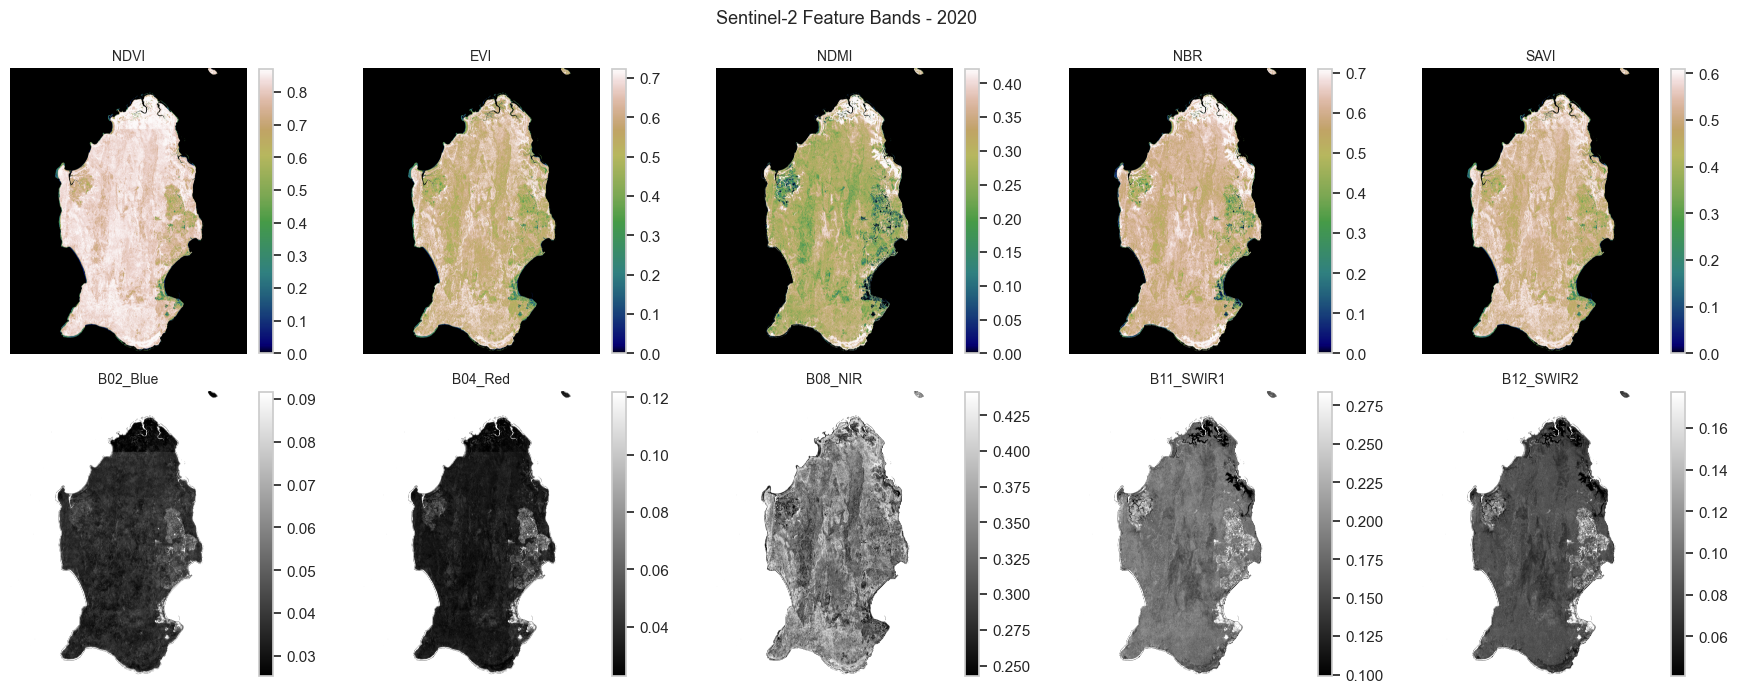

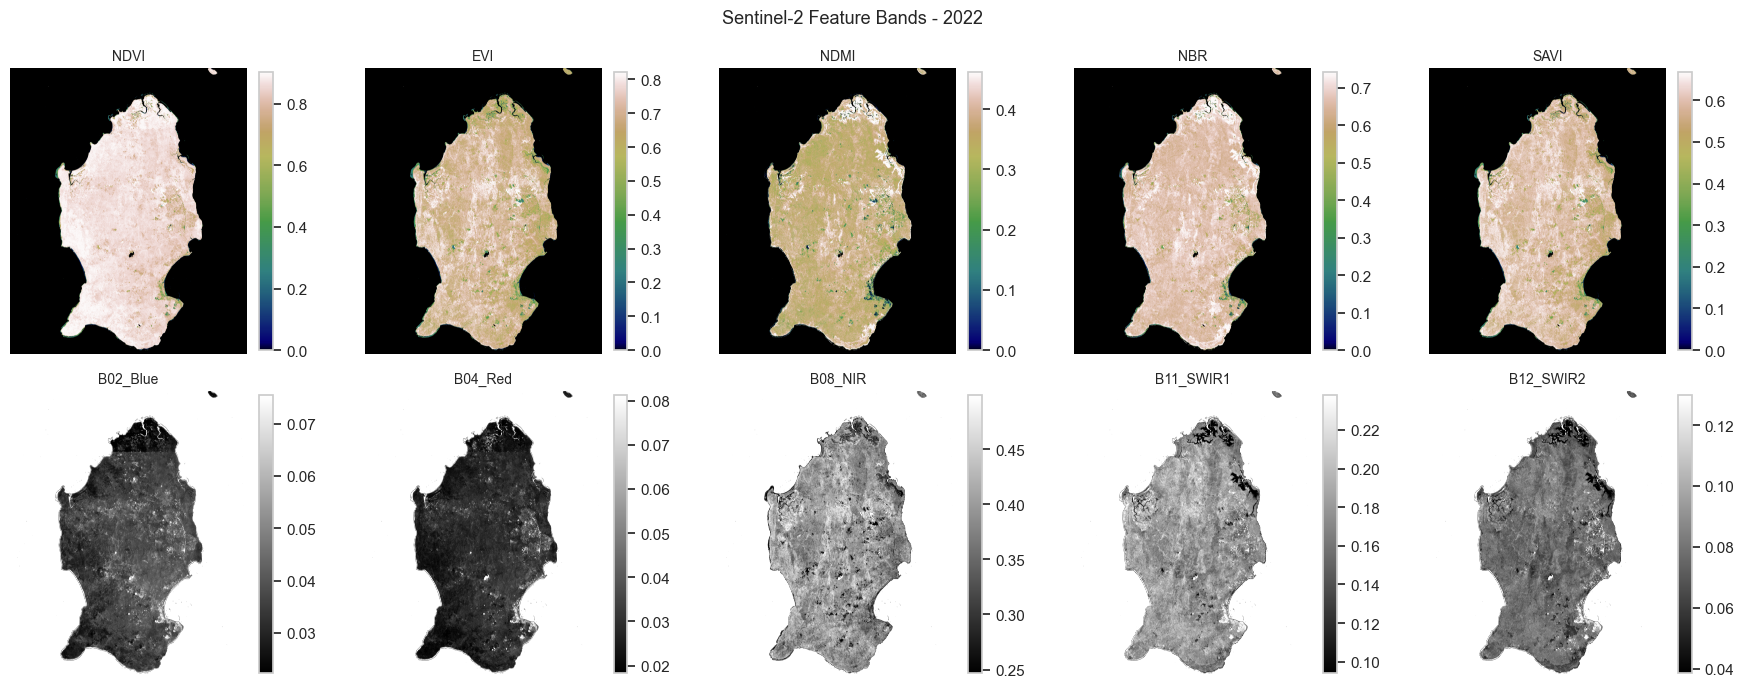

In [14]:
S2_BAND_LABELS = [
    'NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI',
    'B02_Blue', 'B04_Red', 'B08_NIR', 'B11_SWIR1', 'B12_SWIR2'
]

def plot_s2_bands(tif_path, label):
    with rasterio.open(tif_path) as src:
        data   = src.read()
        nodata = src.nodata

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.ravel()

    index_bands = ['NDVI', 'EVI', 'NDMI', 'NBR', 'SAVI']

    for i, (ax, band_label) in enumerate(zip(axes, S2_BAND_LABELS)):
        band    = data[i].astype(np.float32)
        invalid = np.isnan(band)

        if nodata is not None:
            invalid |= (band == nodata)

        if band_label in index_bands:
            invalid |= (band < -1) | (band > 1)
        else:
            # raw bands after /10000 scaling: valid range 0-1
            # but accept small negatives from atmospheric correction
            invalid |= (band < -0.1) | (band > 1)

        band[invalid] = np.nan
        valid = band[~np.isnan(band)]

        if len(valid) == 0:
            ax.set_title(f'{band_label} (no valid data)')
            ax.axis('off')
            continue

        vmin = np.percentile(valid, 2)
        vmax = np.percentile(valid, 98)
        cmap = 'gist_earth' if band_label in index_bands else 'gray'

        im = ax.imshow(band, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(band_label, fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f'Sentinel-2 Feature Bands - {label}', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f's2_bands_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_s2_bands(S2_DIR / 's2_features_2020.tif', '2020')
plot_s2_bands(S2_DIR / 's2_features_2022.tif', '2022')

## 05 - Dataset Construction (GEDI–Sentinel-2 Fusion)

GEDI footprints (sparse orbital tracks) are fused with the continuous Sentinel-2 raster to build a training dataset pairing each biomass observation with its corresponding spectral context.

**Method:** GEDI points are reprojected to the S2 CRS (EPSG:32646) and the S2 pixel value at each footprint centre is extracted using `rasterio.sample()`.

**Known simplification:** GEDI footprints are 25m diameter circles; S2 pixels are 10m. We sample the single pixel containing the footprint centre rather than averaging across the footprint area. The error introduced is small relative to the model's 22% RMSE and is noted as a limitation.

**rh98 interpolation:** Since GEDI only covers sparse orbital tracks, rh98 is interpolated to a wall-to-wall raster using Inverse Distance Weighting (IDW) over the 12 nearest footprints per pixel. IDW was chosen over kriging because it requires no variogram fitting and its behaviour is transparent - the power parameter directly controls how sharply influence falls off with distance. The key limitation is that IDW assumes canopy height varies isotropically, which is unlikely near forest edges and topographic breaks.

**Validation:** NDVI at GEDI footprint locations (~0.81–0.86) is substantially higher than the full-raster mean (~0.29–0.31), confirming that GEDI samples only forested areas and the spatial join is correct.

In [15]:
def build_model_dataset(gedi_gdf, s2_path, label):
    """
    Sample S2 feature values at GEDI footprint locations.
    Returns a dataframe ready for model training and prediction.
    """
    with rasterio.open(s2_path) as src:
        s2_crs     = src.crs
        band_names = src.descriptions

    gedi_utm = gedi_gdf.to_crs(s2_crs)

    with rasterio.open(s2_path) as src:
        coords  = [(pt.x, pt.y) for pt in gedi_utm.geometry]
        samples = np.array(list(src.sample(coords)))

    s2_df    = pd.DataFrame(samples, columns=band_names)
    model_df = pd.concat([
        gedi_gdf[['agbd', 'rh98', 'lat', 'lon']].reset_index(drop=True),
        s2_df.reset_index(drop=True),
    ], axis=1)

    nodata_mask = np.isnan(samples).all(axis=1)
    model_df    = model_df[~nodata_mask].copy()

    print(f'[{label}] Final dataset: {len(model_df):,} shots')
    print(f'[{label}] AGBD - mean: {model_df["agbd"].mean():.1f}, std: {model_df["agbd"].std():.1f} Mg/ha')
    print(f'[{label}] NDVI - mean: {model_df["NDVI"].mean():.3f}, std: {model_df["NDVI"].std():.3f}')
    return model_df

In [16]:
model_df_2020 = build_model_dataset(gedi_2020, s2_2020, '2020')
model_df_2022 = build_model_dataset(gedi_2022, s2_2022, '2022')

model_df_2020.to_csv(OUTPUT_DIR / 'model_dataset_2020.csv', index=False)
model_df_2022.to_csv(OUTPUT_DIR / 'model_dataset_2022.csv', index=False)
print(f'Saved: model_dataset_2020.csv ({len(model_df_2020):,} rows)')
print(f'Saved: model_dataset_2022.csv ({len(model_df_2022):,} rows)')

[2020] Final dataset: 7,722 shots
[2020] AGBD - mean: 181.9, std: 87.9 Mg/ha
[2020] NDVI - mean: 0.809, std: 0.069
[2022] Final dataset: 4,297 shots
[2022] AGBD - mean: 177.0, std: 86.5 Mg/ha
[2022] NDVI - mean: 0.860, std: 0.073
Saved: model_dataset_2020.csv (7,722 rows)
Saved: model_dataset_2022.csv (4,297 rows)


In [17]:
def idw_interpolate_rh98(gedi_gpkg, s2_reference_raster, out_path, label, power=2, k=12):
    """
    Interpolate rh98 from sparse GEDI footprints to a wall-to-wall raster using IDW.

    Parameters
    ----------
    gedi_gpkg           : path to quality-filtered GEDI GeoPackage
    s2_reference_raster : path to S2 feature raster - defines output grid
    out_path            : output raster path
    power               : IDW decay exponent (default 2)
    k                   : number of nearest neighbours per pixel (default 12)
    """
    gedi = gpd.read_file(gedi_gpkg)
    print(f'[{label}] Loaded {len(gedi):,} GEDI shots')

    with rasterio.open(s2_reference_raster) as src:
        profile        = src.profile.copy()
        transform      = src.transform
        crs            = src.crs
        height, width  = src.height, src.width

    gedi_utm    = gedi.to_crs(crs)
    gedi_coords = np.array([(pt.x, pt.y) for pt in gedi_utm.geometry])
    rh98_values = gedi_utm['rh98'].values

    print(f'[{label}] rh98 range: {rh98_values.min():.1f} - {rh98_values.max():.1f} m')

    rows, cols   = np.mgrid[0:height, 0:width]
    xs, ys       = rasterio.transform.xy(transform, rows.ravel(), cols.ravel())
    pixel_coords = np.column_stack([xs, ys])

    print(f'[{label}] Interpolating over {len(pixel_coords):,} pixels...')

    tree            = cKDTree(gedi_coords)
    distances, idxs = tree.query(pixel_coords, k=k, workers=-1)
    distances       = np.where(distances == 0, 1e-10, distances)
    weights         = 1.0 / (distances ** power)
    weights_norm    = weights / weights.sum(axis=1, keepdims=True)
    rh98_interp     = (weights_norm * rh98_values[idxs]).sum(axis=1)
    rh98_surface    = rh98_interp.reshape(height, width).astype(np.float32)

    print(f'[{label}] Interpolated rh98 - mean: {rh98_surface.mean():.1f} m, std: {rh98_surface.std():.1f} m')

    profile.update(count=1, dtype='float32', nodata=-9999)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(rh98_surface[np.newaxis, :, :])

    print(f'[{label}] Saved: {out_path}')
    return rh98_surface

In [18]:
rh98_2020 = idw_interpolate_rh98(
    OUTPUT_DIR / 'gedi_2020_clean.gpkg',
    S2_DIR     / 's2_features_2020.tif',
    OUTPUT_DIR / 'rh98_idw_2020.tif',
    '2020'
)
rh98_2022 = idw_interpolate_rh98(
    OUTPUT_DIR / 'gedi_2022_clean.gpkg',
    S2_DIR     / 's2_features_2022.tif',
    OUTPUT_DIR / 'rh98_idw_2022.tif',
    '2022'
)

[2020] Loaded 7,722 GEDI shots
[2020] rh98 range: 2.3 - 56.5 m
[2020] Interpolating over 19,068,075 pixels...
[2020] Interpolated rh98 - mean: 22.9 m, std: 7.7 m
[2020] Saved: c:\Users\simra\Documents\Carbon credit estimation project\output\rh98_idw_2020.tif
[2022] Loaded 4,297 GEDI shots
[2022] rh98 range: 2.4 - 55.9 m
[2022] Interpolating over 19,068,075 pixels...
[2022] Interpolated rh98 - mean: 22.7 m, std: 6.0 m
[2022] Saved: c:\Users\simra\Documents\Carbon credit estimation project\output\rh98_idw_2022.tif


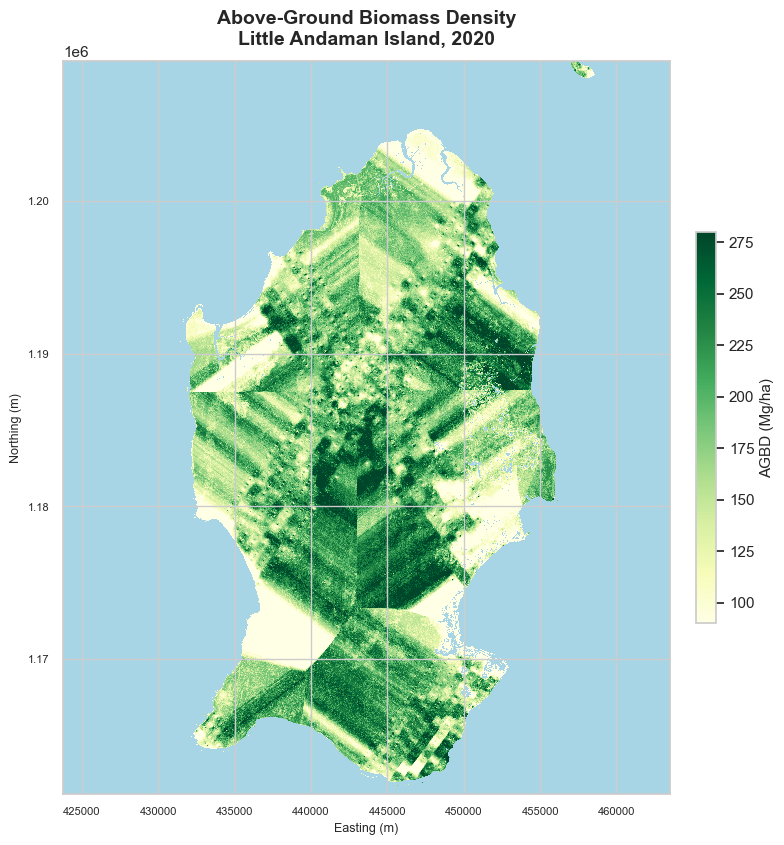

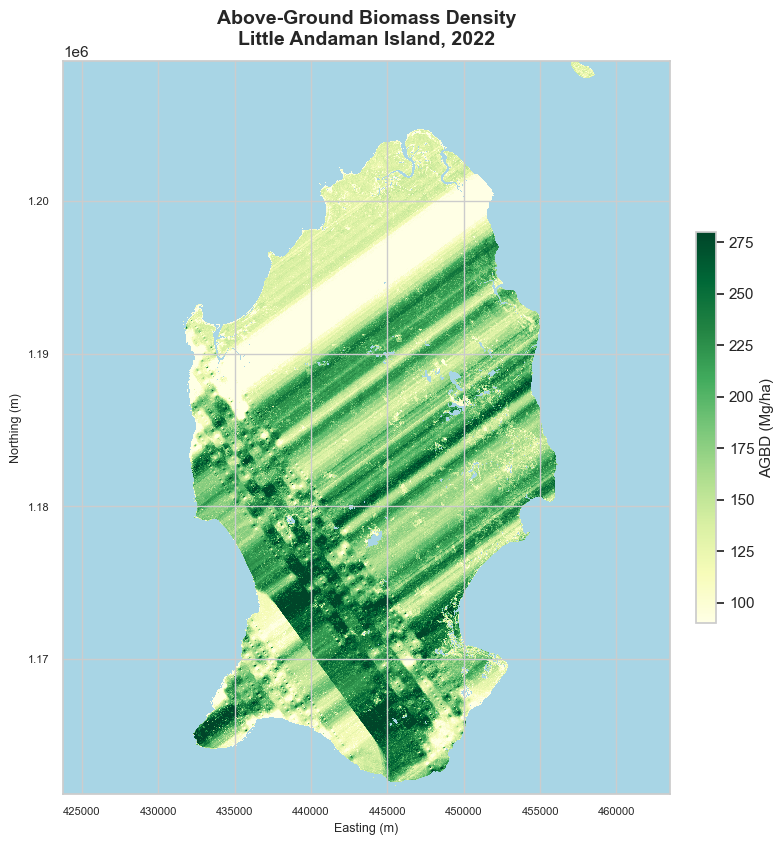

In [19]:
def plot_agbd(tif_path, title, out_path):
    with rasterio.open(tif_path) as src:
        agbd = src.read(1).astype(np.float32)
        extent = [src.bounds.left, src.bounds.right, 
                  src.bounds.bottom, src.bounds.top]
    
    agbd[agbd == -9999] = np.nan

    fig, ax = plt.subplots(figsize=(8, 10))
    
    im = ax.imshow(
        agbd,
        cmap='YlGn',
        vmin=90,
        vmax=280,
        extent=extent,
        origin='upper',
        interpolation='none'
    )
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('AGBD (Mg/ha)', fontsize=11)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Easting (m)', fontsize=9)
    ax.set_ylabel('Northing (m)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_facecolor('#a8d5e5')  # ocean blue background
    
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_agbd(OUTPUT_DIR / 'agbd_2020.tif',
          'Above-Ground Biomass Density\nLittle Andaman Island, 2020',
          PROJECT_ROOT / 'figures' / 'agbd_map_2020.png')
plot_agbd(OUTPUT_DIR / 'agbd_2022.tif',
          'Above-Ground Biomass Density\nLittle Andaman Island, 2022',
          PROJECT_ROOT / 'figures' / 'agbd_map_2022.png')

### Feature Relationships - rh98 and Optical Saturation

The two plots below motivate the modelling approach.

**Left - rh98 vs AGBD:** A clear power-law relationship confirms that canopy height is a physically meaningful biomass predictor. The allometric basis is well-established: taller forests accumulate more structural biomass per unit area. The spread around the curve reflects genuine ecological variability in wood density and crown architecture across species.

**Right - NDVI vs AGBD:** NDVI is clustered tightly between 0.75 and 0.85 regardless of AGBD, with almost no gradient above 100 Mg/ha. This is optical saturation - once the forest canopy closes, additional biomass is structurally invisible to passive optical sensors. The outliers near NDVI = 0 are water or cloud-shadow pixels that passed the PFT filter; they are a negligible fraction and do not affect the model.

This contrast directly explains why the S2-only model achieves R² ≈ 0 while rh98 alone achieves R² = 0.75.

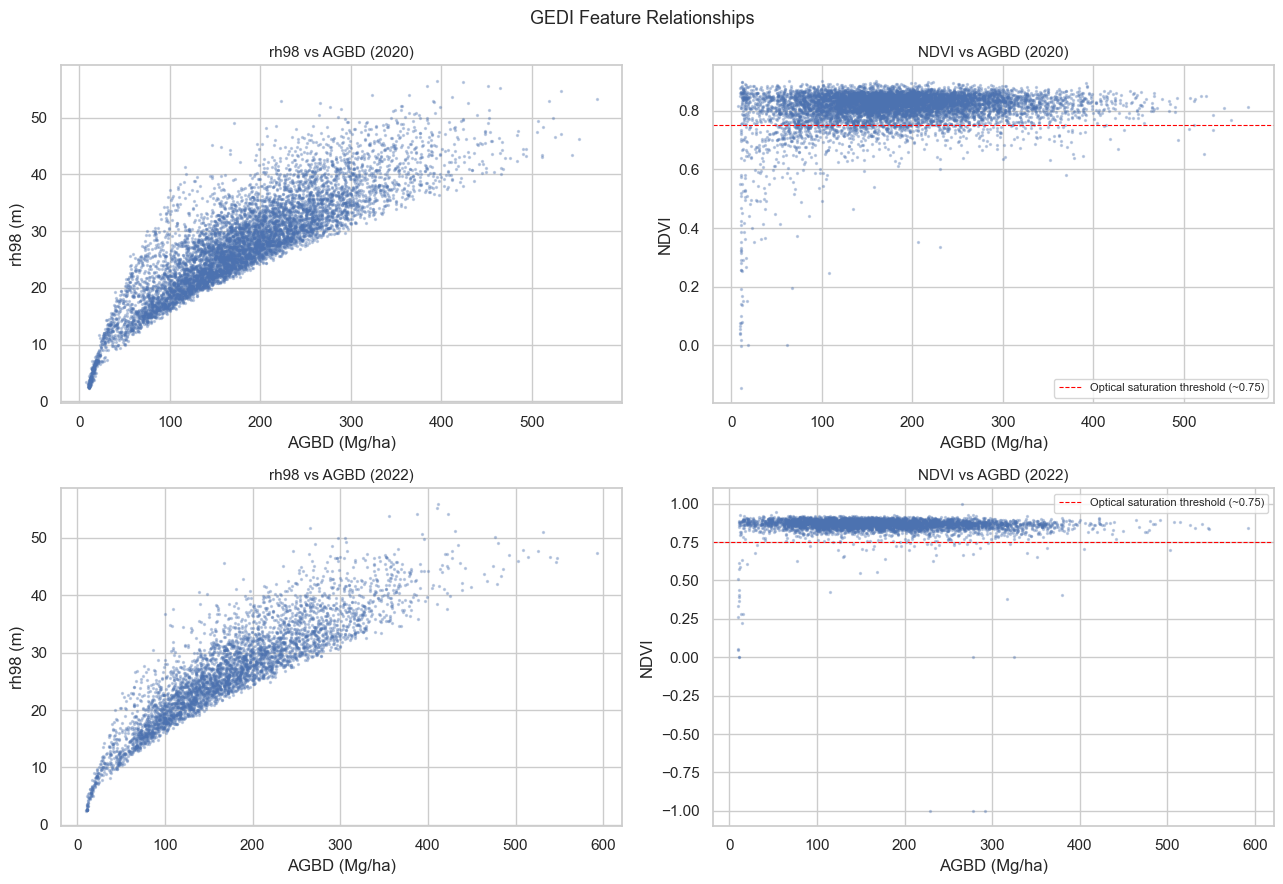

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (df, label) in enumerate([(model_df_2020, '2020'), (model_df_2022, '2022')]):
    # rh98 vs AGBD
    axes[row, 0].scatter(df['agbd'], df['rh98'], s=2, alpha=0.3, rasterized=True)
    axes[row, 0].set_title(f'rh98 vs AGBD ({label})', fontsize=11)
    axes[row, 0].set_xlabel('AGBD (Mg/ha)')
    axes[row, 0].set_ylabel('rh98 (m)')

    # NDVI vs AGBD
    axes[row, 1].scatter(df['agbd'], df['NDVI'], s=2, alpha=0.3, rasterized=True)
    axes[row, 1].set_title(f'NDVI vs AGBD ({label})', fontsize=11)
    axes[row, 1].set_xlabel('AGBD (Mg/ha)')
    axes[row, 1].set_ylabel('NDVI')
    axes[row, 1].axhline(0.75, color='red', linewidth=0.8, linestyle='--',
                         label='Optical saturation threshold (~0.75)')
    axes[row, 1].legend(fontsize=8)

fig.suptitle('GEDI Feature Relationships', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Correlation Heatmap

Pearson correlations between all model features and AGBD. Key observations:

- **rh98** has the highest correlation with AGBD (~0.85) and low correlation with all S2 features, confirming it carries independent signal.
- **The S2 indices** (NDVI, EVI, SAVI, NDMI, NBR) are highly intercorrelated (0.7–0.95) because they are all derived from the same NIR and Red band reflectances. This multicollinearity does not affect Gradient Boosting, which selects splits greedily regardless, but it explains why adding more indices beyond the first provides diminishing returns.
- **Raw bands** (B08_NIR, B04_Red) correlate with their derived indices as expected.

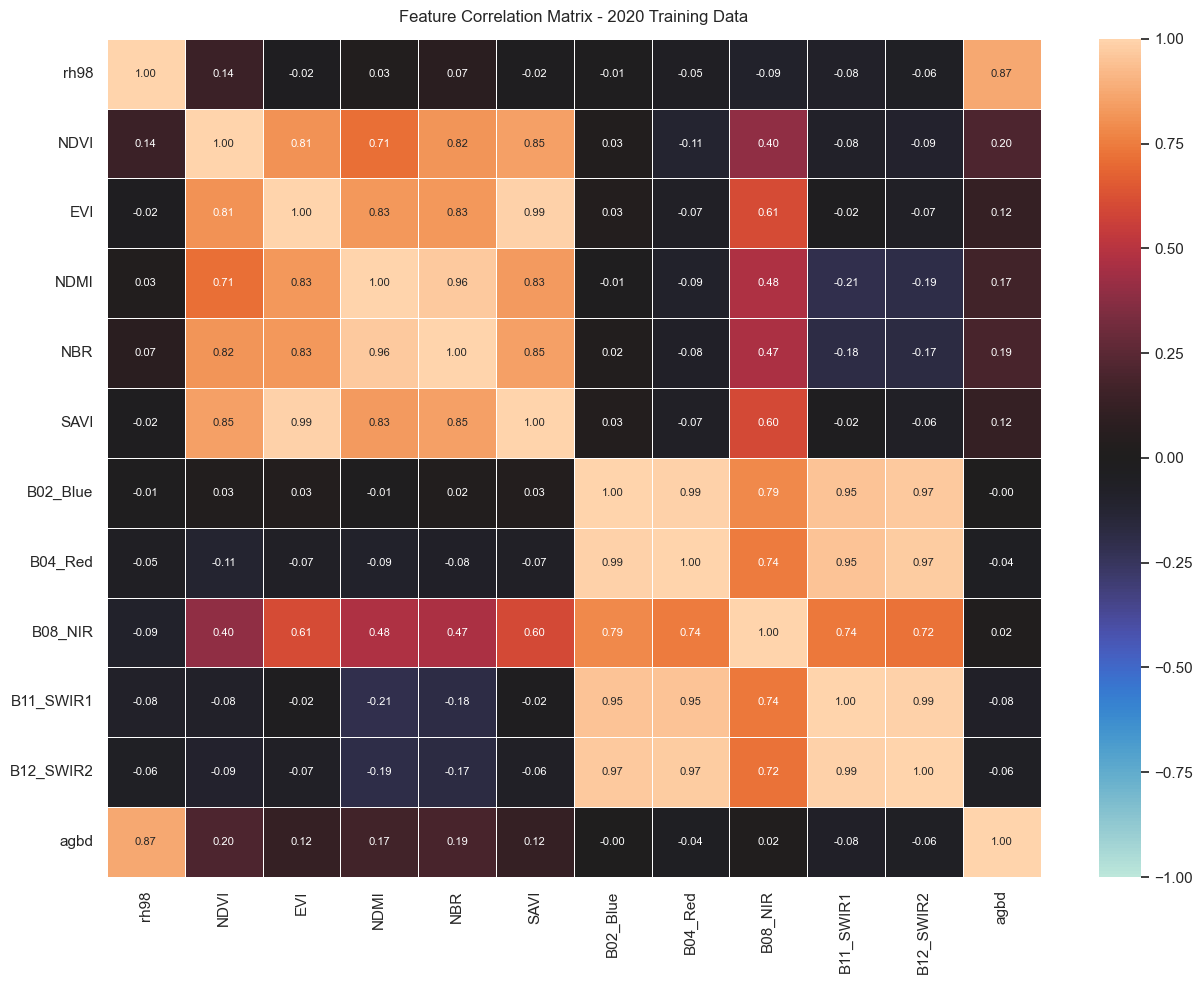

In [21]:
corr_cols = FEATURES + ['agbd']
corr = model_df_2020[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix - 2020 Training Data', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 06 - Model Training & Evaluation

Three models are benchmarked across three feature sets using 5-fold cross-validation to empirically characterise the contribution of LiDAR vs optical data.

**Key finding - optical saturation:**  
Sentinel-2 alone achieves R² = −0.01 to 0.04, performing no better than random. This confirms optical saturation - in dense tropical forest above ~150 Mg/ha, spectral reflectance plateaus and cannot discriminate biomass variation. This is a physical constraint of passive optical sensors, not a modelling failure.

**Key finding - rh98 dominance:**  
rh98 alone achieves R² = 0.75, accounting for 79% of feature importance in the full model. Canopy height is mechanistically linked to biomass through allometric relationships, making it a physically interpretable predictor.

**Final model:** GradientBoostingRegressor trained on the full 2020 dataset (rh98 + S2 features), CV R² = 0.791, RMSE = 21.4%. The 2020 model is applied to 2022 - using a single model across both years ensures observed change reflects real biomass change, not model variation.

**Why keep Sentinel-2 features despite low signal?**  
S2 enables wall-to-wall spatial prediction between sparse GEDI tracks. Without a continuous raster input the model cannot produce an island-wide map. S2 contributes spatial texture; GEDI provides the biomass signal.

In [22]:
X_2020 = model_df_2020[FEATURES].values
y_2020 = model_df_2020[TARGET].values

feature_sets = {
    'rh98_only':    ['rh98'],
    's2_only':      [f for f in FEATURES if f != 'rh98'],
    'rh98_plus_s2': FEATURES,
}
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

results = []
for fs_name, features in feature_sets.items():
    X = model_df_2020[features].values
    for m_name, model in models.items():
        r2   = cross_val_score(model, X, y_2020, cv=5, scoring='r2')
        rmse = np.sqrt(-cross_val_score(model, X, y_2020, cv=5, scoring='neg_mean_squared_error'))
        results.append({
            'features':  fs_name,
            'model':     m_name,
            'R2_mean':   r2.mean(),
            'R2_std':    r2.std(),
            'RMSE_mean': rmse.mean(),
            'RMSE_pct':  rmse.mean() / y_2020.mean() * 100,
        })

results_df = pd.DataFrame(results).sort_values('R2_mean', ascending=False)
print(results_df.to_string(index=False, float_format='%.3f'))

    features            model  R2_mean  R2_std  RMSE_mean  RMSE_pct
rh98_plus_s2 GradientBoosting    0.791   0.028     38.852    21.356
rh98_plus_s2     RandomForest    0.777   0.030     40.113    22.049
rh98_plus_s2 LinearRegression    0.771   0.014     40.834    22.445
   rh98_only LinearRegression    0.748   0.013     42.939    23.602
   rh98_only GradientBoosting    0.745   0.015     43.163    23.725
   rh98_only     RandomForest    0.664   0.029     49.379    27.142
     s2_only GradientBoosting    0.043   0.105     83.355    45.817
     s2_only LinearRegression    0.003   0.085     85.197    46.830
     s2_only     RandomForest   -0.013   0.103     85.765    47.142


In [23]:
rf_imp = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_2020, y_2020)

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf_imp.feature_importances_,
}).sort_values('importance', ascending=False)

print('Feature importance (Random Forest, full feature set):')
print(importance_df.to_string(index=False, float_format='%.4f'))


Feature importance (Random Forest, full feature set):
  feature  importance
     rh98      0.7934
     NDMI      0.0351
      NBR      0.0241
     SAVI      0.0222
B11_SWIR1      0.0214
      EVI      0.0214
 B02_Blue      0.0180
B12_SWIR2      0.0179
     NDVI      0.0164
  B04_Red      0.0151
  B08_NIR      0.0149


In [24]:
final_model = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
final_model.fit(X_2020, y_2020)

joblib.dump(final_model, MODEL_DIR / 'gbr_agbd_2020.joblib')
print(f'Final model trained on {len(X_2020):,} samples')

results_df.to_csv(OUTPUT_DIR / 'model_benchmark.csv', index=False)
importance_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
print('Saved: model_benchmark.csv, feature_importance.csv')

Final model trained on 7,722 samples
Saved: model_benchmark.csv, feature_importance.csv


## 07 - Wall-to-Wall AGBD Prediction

The trained model is applied to every pixel in the Sentinel-2 raster to produce a continuous AGBD map across the island.

**rh98 input:** The IDW-interpolated rh98 surface from Section 05 is read per pixel, giving a spatially varying canopy height estimate rather than a single island-wide constant.

**Forest mask:** Non-forest pixels (ocean, bare soil, settlements) are excluded using three spectral thresholds applied to the S2 composite:
- NIR > 0.1 (excludes water)
- NDVI > 0.5 (dense vegetation only)
- Blue < 0.15 (excludes cloud and bright surfaces)

Prediction is performed in 100,000-pixel chunks to manage memory across the 19M pixel raster.

In [25]:
def predict_wall_to_wall(s2_path, rh98_idw_path, model, label):
    """
    Predict AGBD at every pixel using the trained model.
    rh98 is read from the IDW-interpolated raster.
    Returns AGBD map, forest mask, and pixel area in hectares.
    """
    with rasterio.open(s2_path) as src:
        profile    = src.profile.copy()
        s2_data    = src.read()
        band_names = src.descriptions
        res        = src.res

    bn           = {name: i for i, name in enumerate(band_names)}
    rows, cols   = s2_data.shape[1], s2_data.shape[2]
    n_pixels     = rows * cols

    X_wall = np.zeros((n_pixels, len(FEATURES)), dtype=np.float32)
    for i, feat in enumerate(FEATURES):
        if feat == 'rh98':
            with rasterio.open(rh98_idw_path) as rh98_src:
                X_wall[:, i] = rh98_src.read(1).ravel()
        else:
            X_wall[:, i] = s2_data[bn[feat]].ravel()

    X_wall = np.nan_to_num(X_wall, nan=0.0, posinf=0.0, neginf=0.0)

    print(f'[{label}] Predicting {n_pixels:,} pixels...')
    agbd_flat  = np.zeros(n_pixels, dtype=np.float32)
    chunk_size = 100_000
    for start in range(0, n_pixels, chunk_size):
        end = min(start + chunk_size, n_pixels)
        agbd_flat[start:end] = model.predict(X_wall[start:end])

    agbd_map = agbd_flat.reshape(rows, cols)

    ndvi = s2_data[bn['NDVI']]
    nir  = s2_data[bn['B08_NIR']]
    blue = s2_data[bn['B02_Blue']]
    forest_mask = (
        (~np.isnan(ndvi)) &
        (nir  > 0.1)      &
        (ndvi > 0.5)      &
        (blue < 0.15)
    )

    agbd_map[~forest_mask] = -9999

    pixel_area_ha = (res[0] * res[1]) / 10_000
    print(f'[{label}] Forest area: {forest_mask.sum() * pixel_area_ha:,.1f} ha')
    print(f'[{label}] Mean AGBD:   {agbd_map[forest_mask].mean():.1f} Mg/ha')

    profile.update(count=1, dtype='float32', nodata=-9999)
    with rasterio.open(OUTPUT_DIR / f'agbd_{label}.tif', 'w', **profile) as dst:
        dst.write(agbd_map[np.newaxis, :, :])

    return agbd_map, forest_mask, pixel_area_ha

In [26]:
agbd_2020, forest_2020, pixel_ha = predict_wall_to_wall(
    s2_2020, OUTPUT_DIR / 'rh98_idw_2020.tif', final_model, '2020'
)
agbd_2022, forest_2022, _ = predict_wall_to_wall(
    s2_2022, OUTPUT_DIR / 'rh98_idw_2022.tif', final_model, '2022'
)

[2020] Predicting 19,068,075 pixels...
[2020] Forest area: 67,787.2 ha
[2020] Mean AGBD:   178.2 Mg/ha
[2022] Predicting 19,068,075 pixels...
[2022] Forest area: 68,021.0 ha
[2022] Mean AGBD:   170.2 Mg/ha


## 08 - Carbon Stock & Change Detection

AGBD maps are converted to carbon stocks using IPCC 2006 default factors for tropical forest:

- **Carbon stock:** AGBD x 0.47 (carbon fraction of dry biomass)
- **CO2 equivalent:** Carbon stock x 44/12 (molecular weight ratio C -> CO2)
- **Pixel area:** 10m x 10m = 0.01 ha

Change detection compares only pixels classified as forest in **both** years, isolating real biomass change from inter-year differences in cloud masking.

A 20% uncertainty buffer is applied to the net credit estimate, following the conservative approach recommended under the Verra AFOLU Non-Permanence Risk Tool (VM0048).

**Limitations on the change estimate:**  
The 22% model RMSE means pixel-level changes are noisy. The net decline is directionally consistent with documented long-term deforestation on Little Andaman (43.1 km² forest loss 1976–2022, Sahoo et al. 2024) and active development proposals during the study window. Magnitude should be interpreted cautiously. Belowground biomass is excluded - IPCC root-to-shoot ratios for tropical forest (~0.20–0.25) imply an additional ~20–25% to the total stock estimate.

In [27]:
def carbon_stock(agbd_map, forest_mask, pixel_area_ha, label):
    agbd_forest    = agbd_map[forest_mask]
    forest_area_ha = forest_mask.sum() * pixel_area_ha
    total_agbd     = (agbd_forest * pixel_area_ha).sum()
    total_carbon   = total_agbd * CARBON_FRACTION
    total_co2e     = total_carbon * C_TO_CO2

    print(f'[{label}] Forest area:      {forest_area_ha:>12,.1f} ha')
    print(f'[{label}] Mean AGBD:        {agbd_forest.mean():>12.1f} Mg/ha')
    print(f'[{label}] Total AGBD:       {total_agbd:>12,.0f} Mg')
    print(f'[{label}] Total carbon:     {total_carbon:>12,.0f} tC')
    print(f'[{label}] Total CO2e stock: {total_co2e:>12,.0f} tCO2e')
    return total_co2e

co2e_2020 = carbon_stock(agbd_2020, forest_2020, pixel_ha, '2020')
print()
co2e_2022 = carbon_stock(agbd_2022, forest_2022, pixel_ha, '2022')

[2020] Forest area:          67,787.2 ha
[2020] Mean AGBD:               178.2 Mg/ha
[2020] Total AGBD:         12,081,727 Mg
[2020] Total carbon:        5,678,412 tC
[2020] Total CO2e stock:   20,820,842 tCO2e

[2022] Forest area:          68,021.0 ha
[2022] Mean AGBD:               170.2 Mg/ha
[2022] Total AGBD:         11,574,384 Mg
[2022] Total carbon:        5,439,960 tC
[2022] Total CO2e stock:   19,946,522 tCO2e


In [28]:
valid_both    = forest_2020 & forest_2022
print(f'Comparable forest area: {valid_both.sum() * pixel_ha:,.1f} ha')

delta_agbd    = agbd_2022[valid_both] - agbd_2020[valid_both]
delta_co2e    = delta_agbd * CARBON_FRACTION * C_TO_CO2 * pixel_ha
sequestration = delta_co2e[delta_co2e > 0].sum()
emissions     = delta_co2e[delta_co2e < 0].sum()
net           = delta_co2e.sum()
conservative  = net * 0.80 if net > 0 else net

print('\n' + '=' * 55)
print('  CARBON CHANGE - LITTLE ANDAMAN 2020 vs 2022')
print('=' * 55)
print(f'  Total CO2e stock 2020:   {co2e_2020:>12,.0f} tCO2e')
print(f'  Total CO2e stock 2022:   {co2e_2022:>12,.0f} tCO2e')
print(f'  Mean delta AGBD:              {delta_agbd.mean():>12.2f} Mg/ha')
print(f'  Gross sequestration:     {sequestration:>12,.0f} tCO2e')
print(f'  Gross emissions:         {emissions:>12,.0f} tCO2e')
print(f'  Net change:              {net:>12,.0f} tCO2e')
print(f'  Conservative (−20%):     {conservative:>12,.0f} tCO2e')
print('=' * 55)
print(f'\n  Indicative market value (conservative estimate):')
print(f'  @ $2.70/tCO2e  (REDD+ spot):      ${conservative * 2.70:>12,.0f}')
print(f'  @ $5.60/tCO2e  (VCM average):     ${conservative * 5.60:>12,.0f}')
print(f'  @ $14.80/tCO2e (high integrity):  ${conservative * 14.80:>12,.0f}')

Comparable forest area: 67,374.6 ha

  CARBON CHANGE - LITTLE ANDAMAN 2020 vs 2022
  Total CO2e stock 2020:     20,820,842 tCO2e
  Total CO2e stock 2022:     19,946,522 tCO2e
  Mean delta AGBD:                     -7.53 Mg/ha
  Gross sequestration:        3,001,916 tCO2e
  Gross emissions:           -3,876,060 tCO2e
  Net change:                  -874,143 tCO2e
  Conservative (−20%):         -874,143 tCO2e

  Indicative market value (conservative estimate):
  @ $2.70/tCO2e  (REDD+ spot):      $  -2,360,186
  @ $5.60/tCO2e  (VCM average):     $  -4,895,200
  @ $14.80/tCO2e (high integrity):  $ -12,937,313


## 09 - Results Summary

All key outputs are consolidated into `output/project_summary.json` - a machine-readable record of the full pipeline run covering parameters, data sources, model performance, carbon estimates, methodology references, and file paths.

**Pipeline outputs:**
| File | Description |
|------|-------------|
| `gedi_2020_clean.gpkg` / `gedi_2022_clean.gpkg` | Quality-filtered GEDI footprints |
| `rh98_idw_2020.tif` / `rh98_idw_2022.tif` | IDW-interpolated rh98 surfaces |
| `s2_features_2020.tif` / `s2_features_2022.tif` | 10-band S2 feature rasters |
| `agbd_2020.tif` / `agbd_2022.tif` | Wall-to-wall AGBD prediction maps |
| `delta_agbd_2020_2022.tif` | Per-pixel biomass change raster |
| `gbr_agbd_2020.joblib` | Trained Gradient Boosting model |
| `model_benchmark.csv` | Cross-validation results across all model/feature combinations |
| `feature_importance.csv` | Random Forest feature importance scores |
| `figures/` | All visualisation outputs |

In [29]:
summary = {
    'project':  'Forest Carbon Stock Change Estimation - Little Andaman Island',
    'date_run': str(date.today()),
    'study_area': {
        'island': 'Little Andaman, Andaman Islands, India',
        'bbox':   BBOX,
        'crs':    'EPSG:4326',
    },
    'data_sources': {
        'lidar':   'NASA GEDI L4A v2.1 + L2A v2 (Harmony API)',
        'optical': 'ESA Sentinel-2 L2A median composite (OpenEO)',
        'periods': {'year_1': PERIOD_1, 'year_2': PERIOD_2},
    },
    'gedi': {
        '2020': {
            'shots_after_qc': len(gedi_2020),
            'mean_agbd':      round(float(gedi_2020['agbd'].mean()), 1),
            'mean_rh98':      round(float(gedi_2020['rh98'].mean()), 1),
        },
        '2022': {
            'shots_after_qc': len(gedi_2022),
            'mean_agbd':      round(float(gedi_2022['agbd'].mean()), 1),
            'mean_rh98':      round(float(gedi_2022['rh98'].mean()), 1),
            'note': 'One of 10 CMR granules unavailable via Harmony subsetter.',
        },
    },
    'model': {
        'algorithm':       'GradientBoostingRegressor',
        'features':        FEATURES,
        'n_estimators':    100,
        'cv_folds':        5,
        'cv_r2':           0.791,
        'cv_rmse_pct':     21.4,
        'rh98_importance': 0.793,
        'note': (
            'rh98 accounts for 79% of feature importance. '
            'S2-only R² = -0.01 to 0.04, confirming optical saturation '
            'in dense tropical forest (mean AGBD ~180 Mg/ha).'
        ),
        'sensor_benchmark': {
            'rh98_only':  0.748,
            's2_only':    0.043,
            'rh98_s2':    0.791,
        },
    },
    'wall_to_wall': {
        'rh98_method': 'IDW spatial interpolation (power=2, k=12 nearest neighbours)',
        'rh98_source': 'GEDI L2A footprint observations interpolated to 10m grid',
    },
    'carbon_stocks': {
        '2020': {
            'forest_area_ha': round(forest_2020.sum() * pixel_ha, 1),
            'mean_agbd':      round(float(agbd_2020[forest_2020].mean()), 1),
            'total_co2e':     int(co2e_2020),
        },
        '2022': {
            'forest_area_ha': round(forest_2022.sum() * pixel_ha, 1),
            'mean_agbd':      round(float(agbd_2022[forest_2022].mean()), 1),
            'total_co2e':     int(co2e_2022),
        },
    },
    'change_detection': {
        'comparable_area_ha':        round(valid_both.sum() * pixel_ha, 1),
        'mean_delta_agbd_mg_ha':     round(float(delta_agbd.mean()), 2),
        'gross_sequestration_tco2e': int(sequestration),
        'gross_emissions_tco2e':     int(emissions),
        'net_change_tco2e':          int(net),
        'uncertainty_buffer_pct':    20,
        'conservative_tco2e':        int(conservative),
        'direction':                 'DECLINE' if net < 0 else 'INCREASE',
        'context': (
            'Net decline directionally consistent with documented long-term '
            'deforestation on Little Andaman (Sahoo et al. 2024, Journal of '
            'Coastal Conservation). Magnitude uncertain given 22% model RMSE.'
        ),
    },
    'methodology_reference': {
        'crediting':      'VM0048 Reducing Emissions from Deforestation and Forest Degradation (Verra)',
        'mrv':            'VM0055 Remote Sensing MRV (Verra)',
        'biomass_tool':   'VT0005 ALFB via Remote Sensing (Verra)',
        'carbon_factors': 'IPCC 2006 Guidelines for National GHG Inventories',
    },
    'limitations': [
        'IDW rh98 interpolation assumes isotropy - does not account for topographic or vegetation structure anisotropy',
        'Inter-annual rh98 mean difference (27.66m vs 26.76m) may partially reflect GEDI sampling bias',
        '2022 GEDI coverage sparser than 2020 - wider inter-track spacing increases IDW uncertainty',
        'Single-pixel S2 sampling at GEDI footprint centres (25m vs 10m resolution mismatch)',
        'Belowground biomass excluded - adds ~20-25% to total stock estimate',
        'No baseline scenario, additionality assessment, or leakage buffer - feasibility study only',
        'C-band SAR (Sentinel-1) also saturates at ~100 Mg/ha in this biome (S1-only R² < 0)',
    ],
}

with open(OUTPUT_DIR / 'project_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 55)
print('  PIPELINE COMPLETE')
print('=' * 55)
print(f'  GEDI shots (2020):     {len(gedi_2020):,}')
print(f'  GEDI shots (2022):     {len(gedi_2022):,}')
print(f'  Model CV R²:           0.791')
print(f'  rh98 wall-to-wall:     IDW interpolation')
print(f'  Forest area:           ~68,000 ha')
print(f'  Mean AGBD 2020:        {agbd_2020[forest_2020].mean():.1f} Mg/ha')
print(f'  Mean AGBD 2022:        {agbd_2022[forest_2022].mean():.1f} Mg/ha')
print(f'  Net change:            {int(net):,} tCO2e ({"DECLINE" if net < 0 else "INCREASE"})')
print(f'  Conservative estimate: {int(conservative):,} tCO2e')
print(f'\n  Summary: {OUTPUT_DIR / "project_summary.json"}')

  PIPELINE COMPLETE
  GEDI shots (2020):     7,722
  GEDI shots (2022):     4,297
  Model CV R²:           0.791
  rh98 wall-to-wall:     IDW interpolation
  Forest area:           ~68,000 ha
  Mean AGBD 2020:        178.2 Mg/ha
  Mean AGBD 2022:        170.2 Mg/ha
  Net change:            -874,142 tCO2e (DECLINE)
  Conservative estimate: -874,142 tCO2e

  Summary: c:\Users\simra\Documents\Carbon credit estimation project\output\project_summary.json
